In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/data_labelled.csv"

In [3]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
irrelevant = ['User_ID']

In [5]:
df = df.drop(columns=irrelevant)

In [6]:
df.Stress_Level.value_counts()

Stress_Level
1    25026
0    24974
Name: count, dtype: int64

In [7]:
X = df.drop('Stress_Level', axis=1)
y = df['Stress_Level']

In [8]:
X = pd.get_dummies(X, drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3> Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [12]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [13]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5015333333333334
              precision    recall  f1-score   support

           0       0.50      0.51      0.51      7492
           1       0.50      0.49      0.50      7508

    accuracy                           0.50     15000
   macro avg       0.50      0.50      0.50     15000
weighted avg       0.50      0.50      0.50     15000



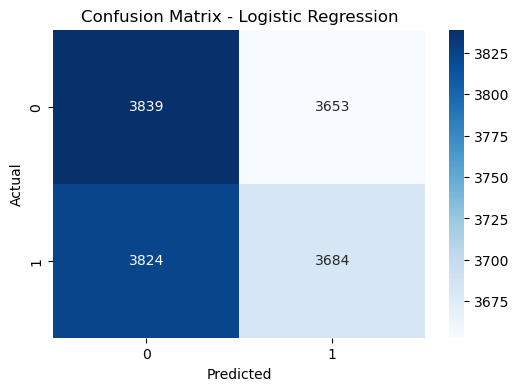

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [15]:
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Random Forest CV Accuracy:", rf_scores.mean())
print("Fold Scores:", rf_scores)

Random Forest CV Accuracy: 0.49548571428571436
Fold Scores: [0.49271429 0.48385714 0.49928571 0.50828571 0.49328571]
